# AI Technical Room Builder
### Generador Inteligente de Presupuestos para Salas Técnicas

Autor: Diego A. Godoy  
Curso: Inteligencia Artificial – Generación de Prompts - Comisión: N° 86420  
Repositorio Drive: https://drive.google.com/drive/folders/1FYNcTPh0Cvxc8RIB5anVgdl6v9RZXKw0?usp=sharing
Proyecto Final

Este proyecto presenta una prueba de concepto que utiliza inteligencia artificial generativa para asistir en la planificación preliminar de infraestructura técnica.

El sistema analiza la descripción de una obra civil asociada a infraestructura técnica como:

- salas de energía
- salas de racks
- salas para grupos electrógenos
- plateas de hormigón para grupos electrógenos

A partir de esta descripción, el modelo genera:

- lista estimada de materiales
- etapas de construcción
- recomendaciones técnicas
- estimación preliminar de presupuesto
- prompt para generar una imagen conceptual del proyecto

## Problema

En proyectos de infraestructura técnica es frecuente necesitar estimaciones rápidas de obra civil para:

- salas de energía
- salas de racks
- salas técnicas de telecomunicaciones
- plateas para grupos electrógenos

Estas estimaciones normalmente requieren experiencia técnica y tiempo de análisis.

La inteligencia artificial generativa permite generar estimaciones preliminares a partir de descripciones simples del proyecto.

In [12]:
# Instalamos la librería de OpenAI

!pip install openai

In [13]:
import json
from openai import OpenAI

In [14]:
import os

os.environ["OPENAI_API_KEY"] = "API_KEY"

client = OpenAI()

## Diseño del Prompt

Se aplican técnicas de Fast Prompting:

- Role Prompting
- Structured Output
- Zero-Shot Prompting

El modelo actuará como un ingeniero civil especializado en infraestructura técnica.

In [15]:
def generar_prompt(descripcion_proyecto):

    prompt = f"""
Actúa como un ingeniero civil especializado en construcción de infraestructura técnica, salas eléctricas y datacenters.

Analiza el siguiente proyecto de obra civil:

{descripcion_proyecto}

Devuelve la respuesta en formato JSON con la siguiente estructura:

{{
"tipo_proyecto": "",
"materiales_estimados": [],
"etapas_construccion": [],
"presupuesto_estimado_usd": "",
"recomendaciones_tecnicas": [],
"prompt_imagen": ""
}}

El campo prompt_imagen debe describir la infraestructura para generar una imagen realista del proyecto.
"""

    return prompt

In [16]:
def consultar_modelo(descripcion):

    prompt = generar_prompt(descripcion)

    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt
    )

    texto = response.output[0].content[0].text

    return texto

## Ejemplo de análisis

En este ejemplo se analiza la construcción de una sala de energía para alojar equipos eléctricos.

In [17]:
descripcion = "Construir una sala de energía de 6x4 metros para alojar UPS y tableros eléctricos"

resultado = consultar_modelo(descripcion)

print(resultado)

{
  "tipo_proyecto": "Sala eléctrica para UPS y tableros eléctricos",
  "materiales_estimados": [
    "Cemento",
    "Arena",
    "Grava",
    "Acero de refuerzo (varillas corrugadas)",
    "Ladrillos o bloques de concreto",
    "Paneles o tabiques divisorios interiores",
    "Puerta metálica con apertura de seguridad",
    "Pintura epóxica para pisos",
    "Revestimiento anti humedad para paredes",
    "Sistema de instalación eléctrica (conductores, canalizaciones, bandejas portacables)",
    "Sistema de iluminación LED de emergencia y normal",
    "Sistema de ventilación o climatización",
    "Aislantes térmicos y acústicos",
    "Materiales para sellado de entrada de cables (pasamuros)",
    "Equipos para puesta a tierra",
    "Sistemas de detección y extinción de incendios (detectores de humo, extintores o sistema FM200/NOVEC)"
  ],
  "etapas_construccion": [
    "Preparación del terreno: limpieza, nivelación y compactación",
    "Cimentación: excavación, formaleta, enfierrado y va

In [18]:
data = json.loads(resultado)

print(json.dumps(data, indent=4))

{
    "tipo_proyecto": "Sala el\u00e9ctrica para UPS y tableros el\u00e9ctricos",
    "materiales_estimados": [
        "Cemento",
        "Arena",
        "Grava",
        "Acero de refuerzo (varillas corrugadas)",
        "Ladrillos o bloques de concreto",
        "Paneles o tabiques divisorios interiores",
        "Puerta met\u00e1lica con apertura de seguridad",
        "Pintura ep\u00f3xica para pisos",
        "Revestimiento anti humedad para paredes",
        "Sistema de instalaci\u00f3n el\u00e9ctrica (conductores, canalizaciones, bandejas portacables)",
        "Sistema de iluminaci\u00f3n LED de emergencia y normal",
        "Sistema de ventilaci\u00f3n o climatizaci\u00f3n",
        "Aislantes t\u00e9rmicos y ac\u00fasticos",
        "Materiales para sellado de entrada de cables (pasamuros)",
        "Equipos para puesta a tierra",
        "Sistemas de detecci\u00f3n y extinci\u00f3n de incendios (detectores de humo, extintores o sistema FM200/NOVEC)"
    ],
    "etapas_cons

In [19]:
print("Tipo de proyecto:")
print(data["tipo_proyecto"])

print("\nMateriales estimados:")
for m in data["materiales_estimados"]:
    print("-", m)

print("\nEtapas de construcción:")
for e in data["etapas_construccion"]:
    print("-", e)

print("\nPresupuesto estimado:")
print(data["presupuesto_estimado_usd"])

print("\nRecomendaciones técnicas:")
for r in data["recomendaciones_tecnicas"]:
    print("-", r)

Tipo de proyecto:
Sala eléctrica para UPS y tableros eléctricos

Materiales estimados:
- Cemento
- Arena
- Grava
- Acero de refuerzo (varillas corrugadas)
- Ladrillos o bloques de concreto
- Paneles o tabiques divisorios interiores
- Puerta metálica con apertura de seguridad
- Pintura epóxica para pisos
- Revestimiento anti humedad para paredes
- Sistema de instalación eléctrica (conductores, canalizaciones, bandejas portacables)
- Sistema de iluminación LED de emergencia y normal
- Sistema de ventilación o climatización
- Aislantes térmicos y acústicos
- Materiales para sellado de entrada de cables (pasamuros)
- Equipos para puesta a tierra
- Sistemas de detección y extinción de incendios (detectores de humo, extintores o sistema FM200/NOVEC)

Etapas de construcción:
- Preparación del terreno: limpieza, nivelación y compactación
- Cimentación: excavación, formaleta, enfierrado y vaciado de losa de cimentación
- Estructura: levantamiento de muros de bloque o ladrillo con refuerzo adecu

## Generación de Prompt para Imagen

El sistema genera automáticamente un prompt que puede utilizarse en herramientas de generación de imágenes para visualizar conceptualmente el proyecto.

In [20]:
print("Prompt para generar imagen:")

print(data["prompt_imagen"])

Prompt para generar imagen:
Render realista de una sala técnica de 6x4 metros construida en concreto y bloques revocados, con puerta metálica de acceso, pisos con pintura epóxica gris, paredes blancas con revestimiento anti humedad, luminarias LED integradas en el techo, bandejas portacables ordenadas a lo largo de las paredes, dos UPS grandes y tableros eléctricos instalados en racks metálicos, sistema de aire acondicionado compacto en una esquina superior, detectores de humo en el techo, y un sistema de puesta a tierra visible cerca de la entrada. La sala está iluminada uniformemente y muestra un ambiente limpio y organizado, con cables debidamente ordenados y etiquetados.


**RESULTADO:**

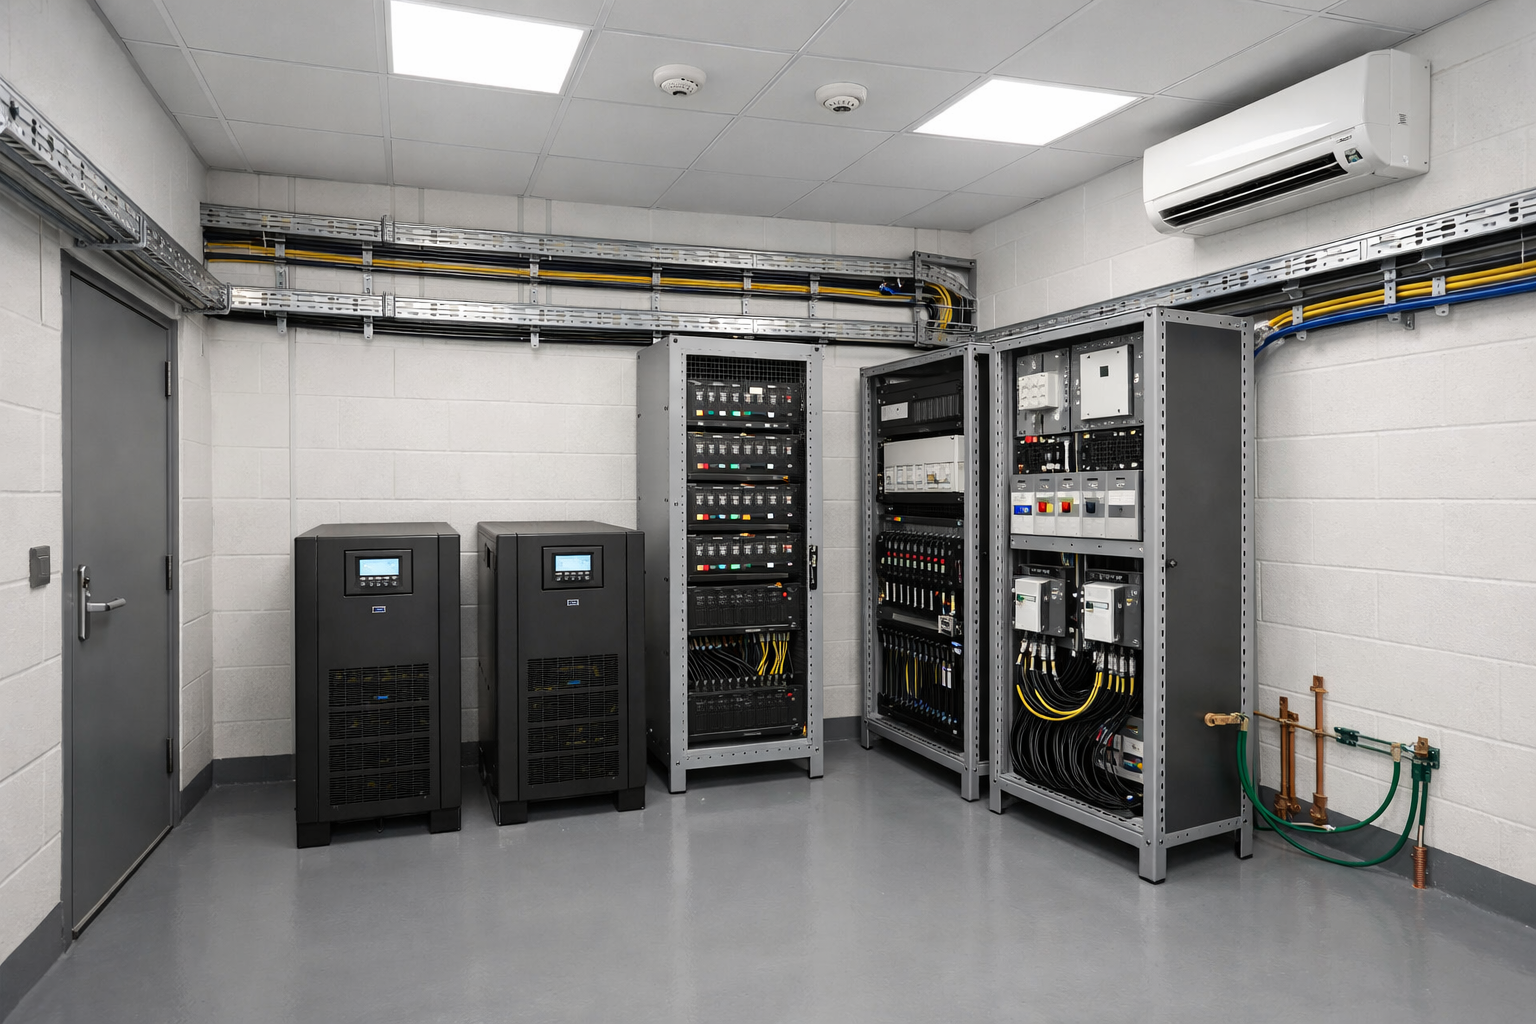

## Segundo ejemplo

Ahora analizaremos la construcción de una platea de hormigón para un grupo electrógeno.

In [21]:
descripcion = "Construir una platea de hormigón para un grupo electrógeno de 800 kVA"

resultado = consultar_modelo(descripcion)

data = json.loads(resultado)

print(json.dumps(data, indent=4))

{
    "tipo_proyecto": "Construcci\u00f3n de platea de hormig\u00f3n para grupo electr\u00f3geno de 800 kVA",
    "materiales_estimados": [
        "Hormig\u00f3n armado (resistencia m\u00ednima f'c=250 kg/cm\u00b2)",
        "Acero de refuerzo (varillas corrugadas #4 y #5)",
        "Grava y arena para mezcla de concreto",
        "Cimbra de madera o met\u00e1lica",
        "Aditivos para hormig\u00f3n (impermeabilizantes y/o plastificantes)",
        "Nivelantes y compactadores",
        "Tuber\u00edas para drenaje (PVC o similar)",
        "Malla electrosoldada",
        "Anclajes y pernos para fijaci\u00f3n del grupo electr\u00f3geno"
    ],
    "etapas_construccion": [
        "1. Estudio y an\u00e1lisis del terreno: verificar capacidad portante y nivelaci\u00f3n.",
        "2. Excavaci\u00f3n y preparaci\u00f3n del terreno seg\u00fan dimensiones de la platea.",
        "3. Colocaci\u00f3n de base granular compactada para soporte uniforme.",
        "4. Instalaci\u00f3n de estruct

## Conclusiones

Este proyecto demuestra cómo la inteligencia artificial generativa puede asistir en la planificación preliminar de infraestructura técnica.

Mediante técnicas de Fast Prompting fue posible generar respuestas estructuradas que incluyen:

- materiales estimados
- etapas de construcción
- recomendaciones técnicas
- estimaciones preliminares de presupuesto
- prompts para visualización del proyecto

Este tipo de herramientas podría integrarse en el futuro con sistemas de presupuestos de obra o plataformas de planificación de infraestructura técnica.